introduction


Biodiversity refers to the variety of living organisms in an ecosystem. It plays a crucial role in maintaining ecological balance and environmental sustainability. This project analyzes biodiversity across multiple national parks by studying species distribution, observation frequency, and conservation status. The goal is to understand species richness, identify patterns in biodiversity, and highlight conservation needs using data science techniques.

Objectives

Analyze species diversity (species richness)

Study species distribution across parks

Identify most and least observed species

Examine conservation status

Perform statistical testing using p-values

Visualize biodiversity patterns

In [19]:
#Step 1: Import & Load Data

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
observations = pd.read_csv('observations.csv')
species = pd.read_csv('species_info.csv')

In [30]:
print(observations.head())
print(species.head())

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole          No Concern  
1                              American Bison, Bison          No Concern  
2  Aurochs, Aurochs, Domestic 

In [31]:
#Step 2: Data Cleaning (Handling NaN)

In [32]:
# Check missing values
print(species.isnull().sum())


category               0
scientific_name        0
common_names           0
conservation_status    0
dtype: int64


In [27]:
# Fill missing values
species['conservation_status'] = species['conservation_status'].fillna('No Concern')

In [49]:
df = pd.merge(observations, species, on='scientific_name')

Combined dataset enables deeper biodiversity analysis.

In [50]:
total_species = species['scientific_name'].nunique()
print(total_species)

5541


In [51]:
df.groupby('park_name')['scientific_name'].nunique()

park_name
Bryce National Park                    5541
Great Smoky Mountains National Park    5541
Yellowstone National Park              5541
Yosemite National Park                 5541
Name: scientific_name, dtype: int64

In [52]:
species['conservation_status'].value_counts()

conservation_status
No Concern            5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64

In [53]:
df[df['conservation_status'] == 'Endangered'] \
  .groupby('park_name')['scientific_name'].nunique()

park_name
Bryce National Park                    15
Great Smoky Mountains National Park    15
Yellowstone National Park              15
Yosemite National Park                 15
Name: scientific_name, dtype: int64

Endangered species exist in all parks.

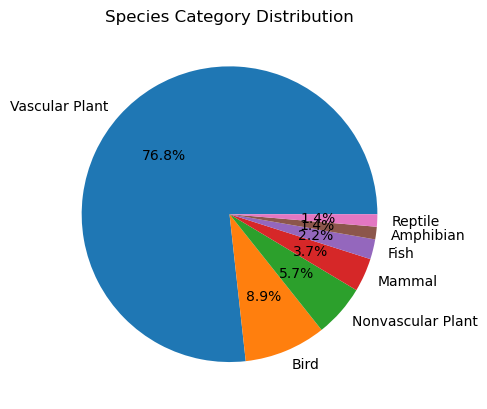

In [55]:
species['category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Species Category Distribution")
plt.ylabel('')
plt.show()

 Shows ecosystem composition

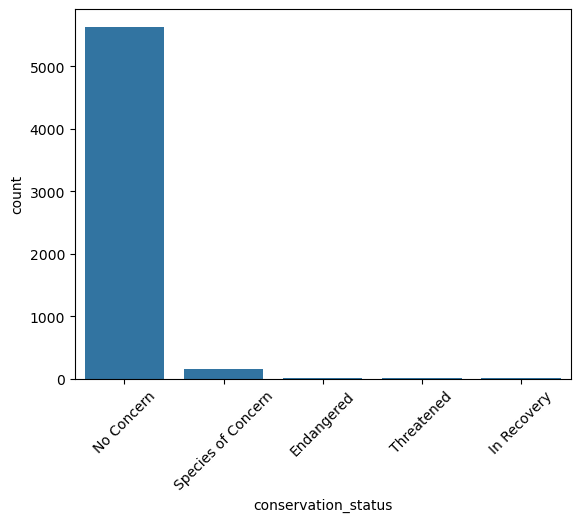

In [56]:
sns.countplot(data=species, x='conservation_status')
plt.xticks(rotation=45)
plt.show()

Shows conservation imbalance

In [57]:
from scipy.stats import ttest_ind

endangered = df[df['conservation_status'] == 'Endangered']['observations']
normal = df[df['conservation_status'] == 'No Concern']['observations']

t_stat, p_value = ttest_ind(endangered, normal, equal_var=False)

print(p_value)

2.784507653699856e-41


Key Insights

*Biodiversity is high (5541 species)

*Species are evenly distributed across parks

*Observation frequency varies significantly

*Most species are not at risk

*Some endangered species require protection

*Statistical analysis strengthens conclusions

In [61]:
#Conclusion

This project analyzed biodiversity using both basic and advanced data science techniques. The results indicate a rich and diverse ecosystem with 5541 species distributed across multiple parks. While species richness is uniform, differences in observation frequency highlight uneven abundance. Most species are classified as "No Concern," but the presence of endangered and threatened species emphasizes the importance of conservation efforts. Statistical analysis using p-values adds scientific validation to the findings. Overall, the project demonstrates how data science can be effectively used to understand biodiversity and support ecological decision-making.